<a href="https://colab.research.google.com/github/muhammad-faizan087/Machine-Learning-Projects/blob/main/Unsupervised%20learning/K_Means_Clustering.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

kMeans -> Centroid based algorithm



In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

make_blobs is used to make dummy datasets (in which samples are distributed in blobs shape), used as a dummy dataset for clustering algos

In [ ]:
X, y = make_blobs(n_samples=500, centers=3, n_features=2, random_state=42)

In [ ]:
X

array([[-5.73035386, -7.58328602],
       [ 1.94299219,  1.91887482],
       [ 6.82968177,  1.1648714 ],
       [-2.90130578,  7.55077118],
       [ 5.84109276,  1.56509431],
       [ 5.47021465,  1.11708586],
       [-4.31954265, -6.97616949],
       [ 4.91033566,  1.92293157],
       [ 3.57225841,  1.8307902 ],
       [-7.50444577, -6.85401854],
       [ 3.99330595,  0.89162168],
       [-1.35060204,  8.19360381],
       [-0.37616425,  7.06219833],
       [-1.93830711, 10.14985177],
       [ 4.92965369,  4.04857048],
       [ 5.69830332,  0.2144302 ],
       [-2.58120774, 10.01781903],
       [-8.00234921, -6.49769985],
       [-6.7973432 , -5.81462922],
       [-3.6155326 ,  7.8180795 ],
       [ 3.24131126,  2.53613892],
       [-2.30033403,  7.054616  ],
       [ 5.2164358 ,  2.28441984],
       [-5.31410316, -6.94585985],
       [-7.32606081, -6.6860196 ],
       [ 5.03433098,  1.5521852 ],
       [ 4.38490162,  3.47716267],
       [-6.09382703, -6.45465203],
       [-6.61257693,

In [ ]:
df = pd.DataFrame(X, columns=['feature 1', 'feature 2'])
df.head()

,feature 1,feature 2
0,-5.730354,-7.583286
1,1.942992,1.918875
2,6.829682,1.164871
3,-2.901306,7.550771
4,5.841093,1.565094


In [ ]:
scaler = StandardScaler()
df_scaled = df.copy()
df_scaled[df.columns] = scaler.fit_transform(df[df.columns])
df_scaled.head()

,feature 1,feature 2
0,-0.864586,-1.378938
1,0.728634,0.076453
2,1.743260,-0.039033
3,-0.277189,0.939058
4,1.537999,0.022266


For getting the best value of k(# of clusters), we use elbow method in which we compare diff values of k with inertia/WCSS(within cluster sum of squares)

In [ ]:
inertia = []
k_range = range(1, 10)
for k in k_range:
    kmeans = KMeans(n_clusters=k)
    kmeans.fit(df_scaled)
    inertia.append(kmeans.inertia_)

Text(0.5, 1.0, 'Elbow Method')

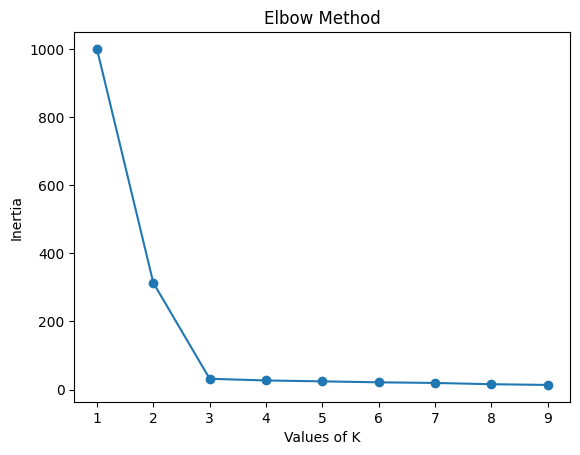

In [ ]:
plt.plot(k_range, inertia, marker='o')
plt.xlabel('Values of K')
plt.ylabel('Inertia')
plt.title('Elbow Method')

so the best value of k is 3

In [ ]:
kmeans_final  = KMeans(n_clusters=3)
cluster_labels = kmeans_final.fit_predict(df_scaled)

In [ ]:
df['clusters'] = cluster_labels
df.head()

,feature 1,feature 2,clusters
0,-5.730354,-7.583286,0
1,1.942992,1.918875,1
2,6.829682,1.164871,1
3,-2.901306,7.550771,2
4,5.841093,1.565094,1


<Axes: xlabel='feature 1', ylabel='feature 2'>

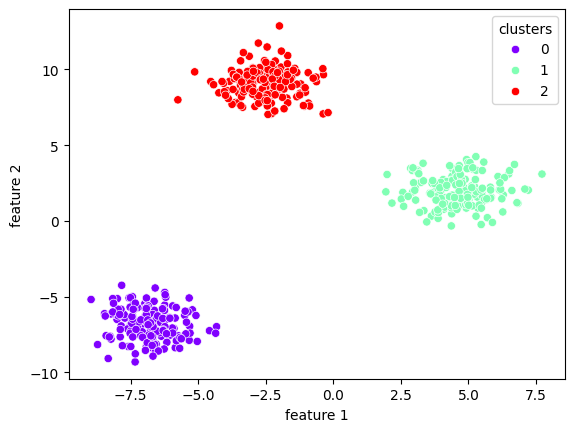

In [ ]:
sns.scatterplot(x=df['feature 1'], y=df['feature 2'], hue=df['clusters'], palette='rainbow')